# Week 4: Supervised Learning Practical
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Design a complete preprocessing pipeline for real-world clinical data
2. Handle class imbalance using SMOTE, class weighting, and proper metrics
3. Compare supervised learning algorithms and select the best for the task
4. Explain model predictions using LIME and SHAP to build clinical trust

**Tools:** Google Colab + Gemini AI
**Dataset:** UCI Heart Disease (Cleveland) — 303 patients, 13 features
**Estimated Time:** 50-60 minutes

---

> **Clinical Scenario (Red Thread):** NCKU Hospital's ER has collected 5 years of
> cardiac data — thousands of patients, dozens of measurements. But when your team
> opens the database: lab values are missing, some patients appear three times
> under different IDs, and for every one cardiac event there are 99 normal visits.
> Your neural network from last week gets 99% accuracy — and misses EVERY heart attack.
> How do you turn this messy, imbalanced data into a model a cardiologist can trust?


## 0. Environment Setup

We need a few additional libraries beyond what Colab provides by default:
- **imbalanced-learn**: SMOTE and other resampling strategies for class imbalance
- **xgboost**: Gradient boosting — the go-to algorithm for tabular clinical data
- **shap**: SHapley Additive exPlanations — model interpretability
- **lime**: Local Interpretable Model-agnostic Explanations


In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
# Install additional libraries (--quiet to reduce output)
!pip install imbalanced-learn --quiet
!pip install xgboost --quiet
!pip install shap --quiet
!pip install lime --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — preprocessing
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Sklearn — metrics
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, matthews_corrcoef, accuracy_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# Interpretability
import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

# Plotting style — handle different matplotlib versions
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass  # fall back to default
sns.set_palette("husl")

# Print versions
print("All libraries loaded successfully!")
print(f"NumPy:            {np.__version__}")
print(f"Pandas:           {pd.__version__}")
print(f"Scikit-learn:     {__import__('sklearn').__version__}")
print(f"imbalanced-learn: {__import__('imblearn').__version__}")
print(f"XGBoost:          {__import__('xgboost').__version__}")
print(f"SHAP:             {shap.__version__}")


All libraries loaded successfully!
NumPy:            2.0.2
Pandas:           2.2.2
Scikit-learn:     1.6.1
imbalanced-learn: 0.14.1
XGBoost:          3.2.0
SHAP:             0.51.0


## 1. Load & Explore UCI Heart Disease Data

The **UCI Heart Disease (Cleveland)** dataset is one of the most widely used
benchmarks in clinical ML. It contains data from 303 patients at the Cleveland
Clinic, with 13 clinical features and a diagnosis of heart disease.

**Clinical Context:** A cardiologist measures these features during a routine
cardiac workup — demographics (age, sex), symptoms (chest pain type), vitals
(resting BP), lab results (cholesterol, fasting blood sugar), and diagnostic
tests (resting ECG, max heart rate during exercise, exercise-induced angina,
ST depression, slope, number of major vessels by fluoroscopy, thalassemia).

Can we predict heart disease from these measurements — and can the prediction
be trusted enough for clinical use?

> **Corresponds to Slide ~S20 (Lab 1)**


In [3]:
# ============================================================
# Section 1: Load UCI Heart Disease (Cleveland)
# ============================================================
# Column names for the Cleveland dataset
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                'ca', 'thal', 'target']

url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'heart-disease/processed.cleveland.data')

try:
    df = pd.read_csv(url, names=column_names, na_values='?')
    print(f"Dataset loaded from UCI repository.")
except Exception as e:
    print(f"Could not load from UCI: {e}")
    print("Generating synthetic fallback dataset...")
    from sklearn.datasets import make_classification
    X_syn, y_syn = make_classification(
        n_samples=303, n_features=13, n_informative=8,
        n_redundant=2, weights=[0.55, 0.45], random_state=42
    )
    df = pd.DataFrame(X_syn, columns=column_names[:-1])
    df['target'] = y_syn
    # Inject some missing values to simulate real data
    rng = np.random.RandomState(42)
    for col in ['ca', 'thal']:
        mask = rng.random(len(df)) < 0.02
        df.loc[mask, col] = np.nan

# Binary target: 0 = no disease, >0 = disease (remap to 1)
df['target'] = (df['target'] > 0).astype(int)

print(f"\nDataset shape: {df.shape}")
print(f"  -> {df.shape[0]} patients, {df.shape[1] - 1} features + 1 target")


Dataset loaded from UCI repository.

Dataset shape: (303, 14)
  -> 303 patients, 13 features + 1 target


In [4]:
# Basic inspection
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nColumn types:")
display(df.dtypes)

print(f"\nFirst 5 rows:")
display(df.head())


DATA OVERVIEW

Column types:


,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64



First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Missing values check
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]

if len(missing_df) > 0:
    print(f"\nColumns with missing values:")
    display(missing_df)
    print(f"\nTotal missing cells: {df.isnull().sum().sum()} "
          f"out of {df.shape[0] * df.shape[1]} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)")
else:
    print("\nNo missing values found!")

print("\nClinical note: 'ca' (number of major vessels colored by fluoroscopy)")
print("and 'thal' (thalassemia) often have missing values in this dataset.")
print("These are invasive/specialized tests — missing data makes clinical sense.")


MISSING VALUES

Columns with missing values:


,Count,Percent
ca,4,1.32
thal,2,0.66



Total missing cells: 6 out of 4242 (0.14%)

Clinical note: 'ca' (number of major vessels colored by fluoroscopy)
and 'thal' (thalassemia) often have missing values in this dataset.
These are invasive/specialized tests — missing data makes clinical sense.


CLASS DISTRIBUTION
  No heart disease (0): 164 patients (54.1%)
  Heart disease (1):    139 patients (45.9%)


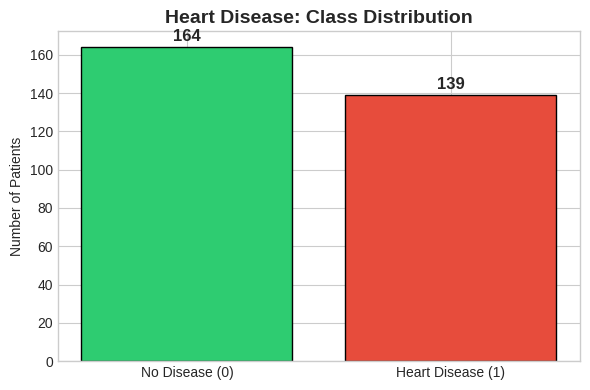


Note: The Cleveland dataset is roughly balanced (~54:46).
We will CREATE artificial imbalance in Section 3 to demonstrate SMOTE.


In [6]:
# Class distribution
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
class_counts = df['target'].value_counts()
print(f"  No heart disease (0): {class_counts.get(0, 0)} patients "
      f"({class_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"  Heart disease (1):    {class_counts.get(1, 0)} patients "
      f"({class_counts.get(1, 0)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ECC71', '#E74C3C']
class_labels = ['No Disease (0)', 'Heart Disease (1)']
bars = ax.bar(class_labels, [class_counts.get(0, 0), class_counts.get(1, 0)],
              color=colors, edgecolor='black')
ax.set_title('Heart Disease: Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\nNote: The Cleveland dataset is roughly balanced (~54:46).")
print("We will CREATE artificial imbalance in Section 3 to demonstrate SMOTE.")


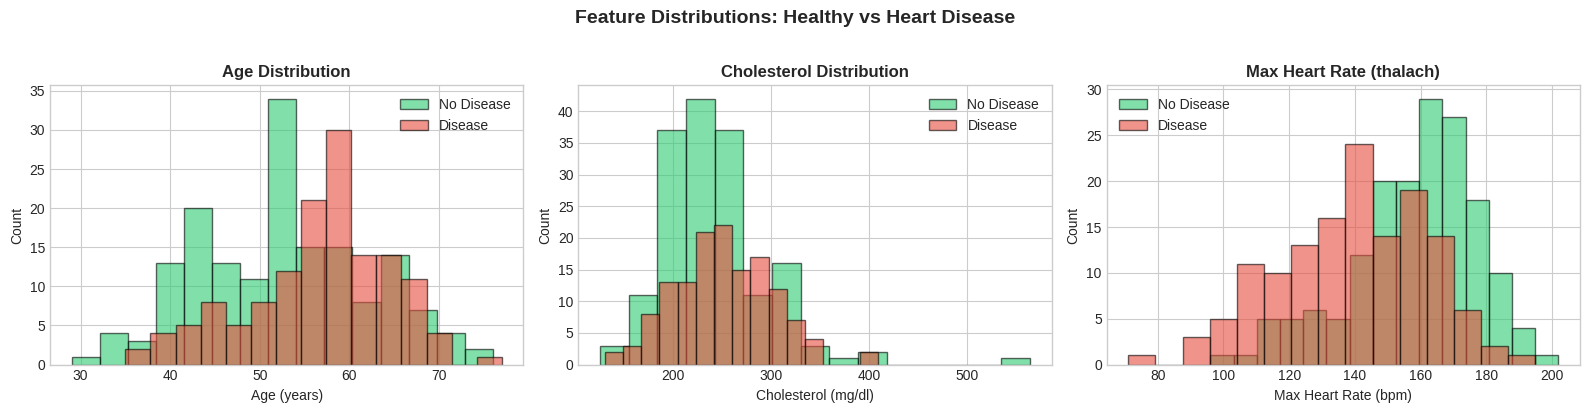

Key observations:
  -> Heart disease patients tend to be slightly older
  -> Cholesterol distributions overlap substantially (weak discriminator)
  -> Heart disease patients tend to have LOWER max heart rate (clinical sense!)


In [7]:
# Feature distributions for key clinical variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution by target
for label, color, name in [(0, '#2ECC71', 'No Disease'), (1, '#E74C3C', 'Disease')]:
    subset = df[df['target'] == label]
    axes[0].hist(subset['age'], bins=15, alpha=0.6, color=color, label=name, edgecolor='black')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Cholesterol distribution by target
for label, color, name in [(0, '#2ECC71', 'No Disease'), (1, '#E74C3C', 'Disease')]:
    subset = df[df['target'] == label]
    axes[1].hist(subset['chol'], bins=15, alpha=0.6, color=color, label=name, edgecolor='black')
axes[1].set_xlabel('Cholesterol (mg/dl)')
axes[1].set_ylabel('Count')
axes[1].set_title('Cholesterol Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

# Max heart rate (thalach) distribution by target
for label, color, name in [(0, '#2ECC71', 'No Disease'), (1, '#E74C3C', 'Disease')]:
    subset = df[df['target'] == label]
    axes[2].hist(subset['thalach'], bins=15, alpha=0.6, color=color, label=name, edgecolor='black')
axes[2].set_xlabel('Max Heart Rate (bpm)')
axes[2].set_ylabel('Count')
axes[2].set_title('Max Heart Rate (thalach)', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('Feature Distributions: Healthy vs Heart Disease',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  -> Heart disease patients tend to be slightly older")
print("  -> Cholesterol distributions overlap substantially (weak discriminator)")
print("  -> Heart disease patients tend to have LOWER max heart rate (clinical sense!)")


## 1.5 Parameter vs Hyperparameter Demo

Before we build pipelines, let's clarify a fundamental distinction:
- **Parameters** are learned FROM the data during training (e.g., tree split thresholds, logistic regression coefficients)
- **Hyperparameters** are set BY YOU before training (e.g., `max_depth`, `n_estimators`, `learning_rate`)

We use the classic **Iris dataset** for a quick, clean demo (we'll return to heart
disease data in Section 2). Changing `max_depth` (a hyperparameter) controls how
complex the tree can grow, which directly affects the number of leaves (a parameter)
and accuracy.

> **Corresponds to Slide ~S8b (Parameter vs Hyperparameter)**


In [8]:
# ============================================================
# Section 1.5: Parameter vs Hyperparameter — DecisionTree Demo
# ============================================================
from sklearn.datasets import load_iris
# DecisionTreeClassifier already imported in Section 0

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Split iris data
X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

print(f"{'max_depth':<12} {'n_leaves (param)':<20} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 56)

depths = [1, 3, 5, None]
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_ir_train, y_ir_train)
    train_acc = tree.score(X_ir_train, y_ir_train)
    test_acc = tree.score(X_ir_test, y_ir_test)
    label = str(d) if d is not None else 'None (unlimited)'
    print(f"{label:<12} {tree.get_n_leaves():<20} {train_acc:<12.4f} {test_acc:<12.4f}")

print("\nKey insight:")
print("  -> max_depth is a HYPERPARAMETER (you choose it before training)")
print("  -> n_leaves and split thresholds are PARAMETERS (learned from data)")
print("  -> Too shallow (depth=1) = underfitting, too deep = overfitting")
print("  -> Hyperparameter tuning (Section 5) finds the sweet spot automatically")


max_depth    n_leaves (param)     Train Acc    Test Acc    
--------------------------------------------------------
1            2                    0.6667       0.6667      
3            5                    0.9810       0.9778      
5            8                    1.0000       0.9333      
None (unlimited) 8                    1.0000       0.9333      

Key insight:
  -> max_depth is a HYPERPARAMETER (you choose it before training)
  -> n_leaves and split thresholds are PARAMETERS (learned from data)
  -> Too shallow (depth=1) = underfitting, too deep = overfitting
  -> Hyperparameter tuning (Section 5) finds the sweet spot automatically


## 2. Data Preprocessing Pipeline

Real clinical data needs systematic preprocessing before any ML model can use it.
We build a **sklearn Pipeline** that automates:
1. **Imputation** — fill missing values (median for numerical, mode for categorical)
2. **Scaling** — standardize numerical features to zero mean + unit variance
3. **Encoding** — convert categorical features to one-hot binary columns

**Why a Pipeline?** It prevents **data leakage** — the scaler fits ONLY on training
data, then transforms both training and test data. Without a Pipeline, you might
accidentally scale based on the entire dataset (including test data), which gives
your model an unfair advantage.

> **Corresponds to Slide ~S22 (Preprocessing Pipeline)**


In [9]:
# ============================================================
# Section 2: Build Preprocessing Pipeline
# ============================================================
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Identify column types (matching V6 slide S22 variable names)
# Numerical: continuous measurements
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Categorical: discrete categories (even if encoded as numbers)
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("Feature types:")
print(f"  Numerical ({len(num_cols)}):  {num_cols}")
print(f"  Categorical ({len(cat_cols)}): {cat_cols}")
print(f"  Total: {len(num_cols) + len(cat_cols)} features")


Feature types:
  Numerical (5):  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Categorical (8): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
  Total: 13 features


In [10]:
# Build the ColumnTransformer
# Numerical: impute missing with median, then scale to zero mean + unit variance
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Median is robust to outliers
    ('scaler', StandardScaler())                     # Zero mean, unit variance
])

# Categorical: impute missing with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Mode imputation
    ('encoder', OneHotEncoder(drop='first',                  # Drop first to avoid collinearity
                              sparse_output=False))         # sparse_output requires sklearn>=1.2
])

# Combine into ColumnTransformer — named 'preprocess' to match V6 slides
# Note: Pipeline.fit() refits the preprocessor. Since all models train
# on the same X_train, the shared object is safe. For different datasets,
# use sklearn.base.clone(preprocess) per pipeline.
preprocess = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Show structure
print("Pipeline structure:")
print(preprocess)


Pipeline structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])


In [11]:
# Demonstrate the transformation (DEMO ONLY -- fits on all data)
# WARNING: In real ML, NEVER fit on all data. We refit on training data in Section 4.
X_transformed = preprocess.fit_transform(X)

print(f"\nOriginal shape:    {X.shape}  (13 features)")
print(f"Transformed shape: {X_transformed.shape}  "
      f"({X_transformed.shape[1]} features after one-hot encoding)")

# Show feature names after transformation
try:
    feature_names = preprocess.get_feature_names_out()
    print(f"\nTransformed feature names ({len(feature_names)}):")
    for i, name in enumerate(feature_names):
        print(f"  [{i:2d}] {name}")
except AttributeError:
    print("\n(Feature names not available in this sklearn version)")

print("\nPipeline prevents data leakage: scaler fits ONLY on training data.")
print("This is critical for honest evaluation of clinical models!")



Original shape:    (303, 13)  (13 features)
Transformed shape: (303, 20)  (20 features after one-hot encoding)

Transformed feature names (20):
  [ 0] num__age
  [ 1] num__trestbps
  [ 2] num__chol
  [ 3] num__thalach
  [ 4] num__oldpeak
  [ 5] cat__sex_1.0
  [ 6] cat__cp_2.0
  [ 7] cat__cp_3.0
  [ 8] cat__cp_4.0
  [ 9] cat__fbs_1.0
  [10] cat__restecg_1.0
  [11] cat__restecg_2.0
  [12] cat__exang_1.0
  [13] cat__slope_2.0
  [14] cat__slope_3.0
  [15] cat__ca_1.0
  [16] cat__ca_2.0
  [17] cat__ca_3.0
  [18] cat__thal_6.0
  [19] cat__thal_7.0

Pipeline prevents data leakage: scaler fits ONLY on training data.
This is critical for honest evaluation of clinical models!


## 3. SMOTE Demonstration: Handling Class Imbalance

The Cleveland dataset is roughly balanced (~54:46), which is unusual for clinical
data. In reality, cardiac events are rare (1-5% of ER visits). To demonstrate the
**class imbalance problem** and **SMOTE** (Synthetic Minority Over-sampling Technique),
we will:

1. **Artificially create 90:10 imbalance** by downsampling the positive class
2. **Apply SMOTE** to synthesize new minority-class patients
3. **Visualize before/after** to see the effect

**Clinical Reality:** In NCKU's ER database, for every 1 cardiac event there are
99 normal visits. A model that always predicts "normal" gets 99% accuracy but
misses every heart attack. SMOTE creates synthetic patients along the lines
connecting real minority-class patients — like generating plausible case
variations for training.

> **Corresponds to Slide ~S15 (SMOTE Pipeline)**


In [47]:
# ============================================================
# Section 3: Create Artificial Imbalance + Apply SMOTE
# ============================================================
# Step 1: Create artificial 90:10 imbalance
# Downsample the positive class (heart disease) to ~10%
np.random.seed(42)

idx_neg = df[df['target'] == 0].index.tolist()  # No disease
idx_pos = df[df['target'] == 1].index.tolist()  # Disease

# Keep all negatives, downsample positives to ~10% of total
n_pos_target = int(len(idx_neg) * 0.10 / 0.90)
idx_pos_down = np.random.choice(idx_pos, size=n_pos_target, replace=False)

idx_imbalanced = np.concatenate([idx_neg, idx_pos_down])
np.random.shuffle(idx_imbalanced)

X_imb = preprocess.fit_transform(X.loc[idx_imbalanced])
y_imb = y.loc[idx_imbalanced].values

print("ARTIFICIAL IMBALANCE CREATED")
print(f"  Total samples:     {len(y_imb)}")
print(f"  No disease (0):    {sum(y_imb == 0)} ({sum(y_imb == 0)/len(y_imb)*100:.1f}%)")
print(f"  Heart disease (1): {sum(y_imb == 1)} ({sum(y_imb == 1)/len(y_imb)*100:.1f}%)")
print(f"\nThis simulates real ER data where cardiac events are rare.")


ARTIFICIAL IMBALANCE CREATED
  Total samples:     182
  No disease (0):    164 (90.1%)
  Heart disease (1): 18 (9.9%)

This simulates real ER data where cardiac events are rare.


In [48]:
# Step 2: Apply SMOTE (guard k_neighbors for small minority class)
n_minority = sum(y_imb == 1)
k = min(5, n_minority - 1)  # SMOTE needs k_neighbors < minority count
smote = SMOTE(k_neighbors=k, random_state=42)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

print("AFTER SMOTE")
print(f"  Total samples:     {len(y_smote)}")
print(f"  No disease (0):    {sum(y_smote == 0)} ({sum(y_smote == 0)/len(y_smote)*100:.1f}%)")
print(f"  Heart disease (1): {sum(y_smote == 1)} ({sum(y_smote == 1)/len(y_smote)*100:.1f}%)")
print(f"\nSMOTE synthesized {sum(y_smote == 1) - sum(y_imb == 1)} new minority-class samples.")


AFTER SMOTE
  Total samples:     328
  No disease (0):    164 (50.0%)
  Heart disease (1): 164 (50.0%)

SMOTE synthesized 146 new minority-class samples.


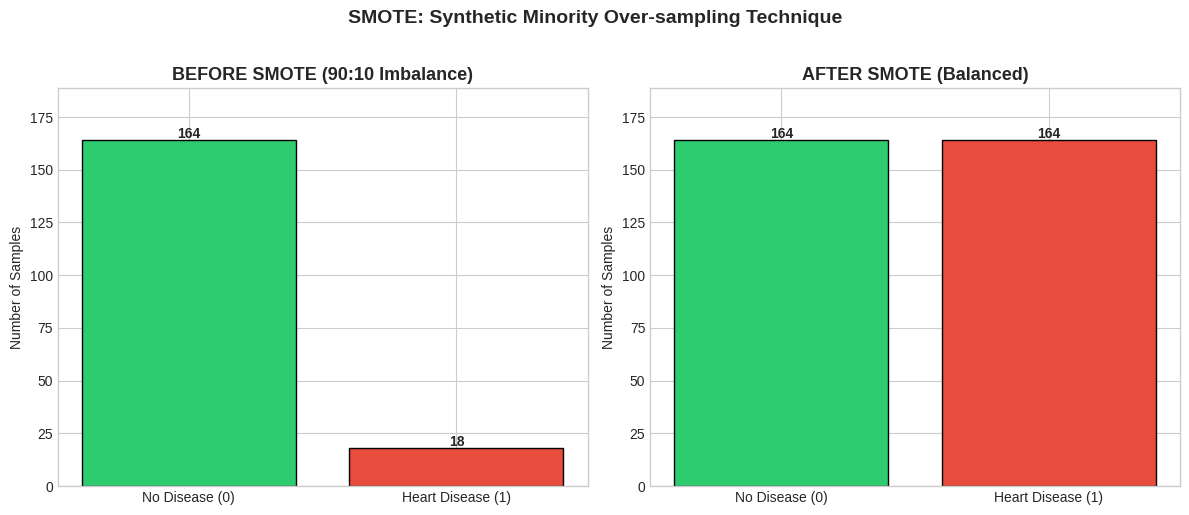

CRITICAL RULE: Apply SMOTE ONLY on training data, NEVER on the test set!
The test set must reflect real-world class distribution.


In [50]:
# Step 3: Before/After Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
labels_before = ['No Disease (0)', 'Heart Disease (1)']
counts_before = [sum(y_imb == 0), sum(y_imb == 1)]
colors = ['#2ECC71', '#E74C3C']
bars1 = axes[0].bar(labels_before, counts_before, color=colors, edgecolor='black')
axes[0].set_title('BEFORE SMOTE (90:10 Imbalance)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# After SMOTE
labels_after = ['No Disease (0)', 'Heart Disease (1)']
counts_after = [sum(y_smote == 0), sum(y_smote == 1)]
bars2 = axes[1].bar(labels_after, counts_after, color=colors, edgecolor='black')
axes[1].set_title('AFTER SMOTE (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Make y-axes consistent for visual impact
max_y = max(max(counts_before), max(counts_after)) * 1.15
axes[0].set_ylim(0, max_y)
axes[1].set_ylim(0, max_y)

plt.suptitle('SMOTE: Synthetic Minority Over-sampling Technique',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("CRITICAL RULE: Apply SMOTE ONLY on training data, NEVER on the test set!")
print("The test set must reflect real-world class distribution.")


### 3b. Alternative: class_weight='balanced'

SMOTE is one way to handle imbalance. Another simpler approach is to tell the
model itself to pay more attention to the minority class via **class_weight='balanced'**.

- **SMOTE**: creates synthetic minority samples in feature space
- **class_weight='balanced'**: adjusts the loss function to penalize minority-class errors more

Both are valid. `class_weight` is simpler (no extra library, no synthetic data),
while SMOTE can help when the decision boundary is complex. In practice, we often
try both and compare.

> **Corresponds to Slide ~S17 (class_weight='balanced')**


In [51]:
# ============================================================
# Section 3b: class_weight='balanced' vs SMOTE
# ============================================================
# Requires: Run Section 3 first (creates X_imb, y_imb)
# Use the artificially imbalanced data to compare approaches
# (cross_val_score already imported in Section 0)

# Split imbalanced data
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb)

# Approach 1: No correction (baseline)
rf_none = RandomForestClassifier(n_estimators=100, random_state=42)
rf_none.fit(X_imb_train, y_imb_train)
y_pred_none = rf_none.predict(X_imb_test)
f1_none = f1_score(y_imb_test, y_pred_none, zero_division=0)

# Approach 2: class_weight='balanced'
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=42)
rf_balanced.fit(X_imb_train, y_imb_train)
y_pred_bal = rf_balanced.predict(X_imb_test)
f1_balanced = f1_score(y_imb_test, y_pred_bal, zero_division=0)

# Approach 3: SMOTE + RF (no class_weight)
smote = SMOTE(random_state=42)
X_smote_tr, y_smote_tr = smote.fit_resample(X_imb_train, y_imb_train)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_smote_tr, y_smote_tr)
y_pred_smote = rf_smote.predict(X_imb_test)
f1_smote = f1_score(y_imb_test, y_pred_smote, zero_division=0)

print("=" * 55)
print("IMBALANCED DATA: THREE APPROACHES COMPARED")
print("=" * 55)
print(f"  {'Approach':<30} {'F1 Score':>10}")
print(f"  {'-'*40}")
print(f"  {'No correction':<30} {f1_none:>10.4f}")
print(f"  {'class_weight=balanced':<30} {f1_balanced:>10.4f}")
print(f"  {'SMOTE + RF':<30} {f1_smote:>10.4f}")
print(f"\nBoth class_weight and SMOTE dramatically improve minority-class detection.")
print(f"For training 4 models at once, class_weight is simpler — we use it in Section 4.")


IMBALANCED DATA: THREE APPROACHES COMPARED
  Approach                         F1 Score
  ----------------------------------------
  No correction                      0.0000
  class_weight=balanced              0.4000
  SMOTE + RF                         0.6667

Both class_weight and SMOTE dramatically improve minority-class detection.
For training 4 models at once, class_weight is simpler — we use it in Section 4.


## 4. Train Multiple Models (ImbPipeline + class_weight)

Now we train four different classifiers on the same preprocessed data and compare
their performance. We use **ImbPipeline** from imbalanced-learn (compatible with
both SMOTE steps and regular classifiers) and **class_weight='balanced'** for
models that support it.

**The four contenders:**
1. **LogReg** — Logistic Regression: simple, interpretable, well-calibrated
2. **RF** — Random Forest: ensemble of decision trees, handles non-linearity
3. **SVM** — Support Vector Machine: finds optimal decision boundary
4. **XGB** — XGBoost: gradient boosting champion for tabular data

**Clinical framing:** Each model is like a different specialist giving their
diagnosis on the same patient chart. We want to see which specialist is most
reliable — and whether they agree.

> **Corresponds to Slide ~S37 (Train & Tune Four Models)**


In [16]:
# ============================================================
# Section 4: Train Four Models on Heart Disease Data
# ============================================================
# Use original data (not the artificially imbalanced version)
X = df.drop('target', axis=1)
y = df['target']

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients")
print(f"  -> No disease in test:    {sum(y_test == 0)}")
print(f"  -> Heart disease in test: {sum(y_test == 1)}")


Training set: 242 patients
Test set:     61 patients
  -> No disease in test:    33
  -> Heart disease in test: 28


In [17]:
# Define 4 classifiers with class_weight / scale_pos_weight (matching V6 S37)
# XGBoost: compute scale_pos_weight dynamically from training data
spw = sum(y_train == 0) / sum(y_train == 1)
print(f"XGB scale_pos_weight = {spw:.2f}  (neg/pos ratio in training data)")

classifiers = {
    'LogReg': LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=42),
    'RF':     RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                     random_state=42),
    'SVM':    SVC(class_weight='balanced', probability=True, random_state=42),
    'XGB':    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                            n_estimators=100, random_state=42, verbosity=0),
}

# Each model wrapped in ImbPipeline: ('pre', preprocess) + ('clf', clf)
models = {}
results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    pipe = ImbPipeline([('pre', preprocess), ('clf', clf)])
    pipe.fit(X_train, y_train)
    models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred),
    }

    print(classification_report(y_test, y_pred,
          target_names=['No Disease', 'Heart Disease']))

print("\nAll 4 models trained successfully!")


XGB scale_pos_weight = 1.18  (neg/pos ratio in training data)

Training: LogReg
               precision    recall  f1-score   support

   No Disease       0.90      0.85      0.88        33
Heart Disease       0.83      0.89      0.86        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.87      0.87      0.87        61


Training: RF
               precision    recall  f1-score   support

   No Disease       0.85      0.85      0.85        33
Heart Disease       0.82      0.82      0.82        28

     accuracy                           0.84        61
    macro avg       0.83      0.83      0.83        61
 weighted avg       0.84      0.84      0.84        61


Training: SVM
               precision    recall  f1-score   support

   No Disease       1.00      0.85      0.92        33
Heart Disease       0.85      1.00      0.92        28

     accuracy                           0.92        61
   

## 5. Hyperparameter Tuning with GridSearchCV

Default hyperparameters are a good starting point, but we can often improve
performance by systematically searching for the best combination. **GridSearchCV**
tests all combinations of specified hyperparameters using cross-validation.

We tune the **Random Forest** as an example. Note the parameter names use
`clf__` prefix because our pipeline step is named `'clf'`.

**Clinical analogy:** Hyperparameter tuning is like adjusting protocol parameters
in a clinical trial — the drug (algorithm) is fixed, but the dose, frequency,
and duration (hyperparameters) are optimized.

> **Corresponds to Slide ~S34 (GridSearchCV)**


In [18]:
# ============================================================
# Section 5: GridSearchCV on Random Forest (ImbPipeline)
# ============================================================
# Define the hyperparameter search space
# Note: 'clf__' prefix matches the pipeline step name ('clf', classifier)
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, 20, None],
    'clf__min_samples_split': [2, 5, 10]
}

# Total combinations: 3 x 4 x 3 = 36 combinations x 5 folds = 180 model fits
print(f"Search space: {3*4*3} combinations x 5 folds = {3*4*3*5} model fits")
print("Running GridSearchCV... (this may take a minute)")

# Create pipeline for tuning (same structure as Section 4)
rf_tune_pipe = ImbPipeline([
    ('pre', preprocess),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Run GridSearchCV
grid_search = GridSearchCV(
    rf_tune_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,       # Use all CPU cores
    verbose=0,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\nBest hyperparameters:")
for param, value in grid_search.best_params_.items():
    clean_name = param.replace('clf__', '')
    print(f"  {clean_name}: {value}")

print(f"\nBest cross-validated F1 score: {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned = grid_search.predict(X_test)
y_proba_tuned = grid_search.predict_proba(X_test)[:, 1]
print(f"Test set F1 score (tuned RF): {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Test set AUC-ROC (tuned RF):  {roc_auc_score(y_test, y_proba_tuned):.4f}")

# Update results and models with tuned RF
results['RF (Tuned)'] = {
    'y_pred': y_pred_tuned,
    'y_proba': y_proba_tuned,
    'f1': f1_score(y_test, y_pred_tuned),
    'auc': roc_auc_score(y_test, y_proba_tuned),
    'mcc': matthews_corrcoef(y_test, y_pred_tuned),
    'accuracy': accuracy_score(y_test, y_pred_tuned),
}
models['RF (Tuned)'] = grid_search.best_estimator_


Search space: 36 combinations x 5 folds = 180 model fits
Running GridSearchCV... (this may take a minute)

Best hyperparameters:
  max_depth: 5
  min_samples_split: 2
  n_estimators: 100

Best cross-validated F1 score: nan
Test set F1 score (tuned RF): 0.8814
Test set AUC-ROC (tuned RF):  0.9416


## 6. Model Comparison: The Fair Competition

Now we compare all models side-by-side using multiple metrics. Remember:
- **Accuracy** alone is misleading (the "99% accuracy trap")
- **F1 Score** balances precision and recall
- **AUC-ROC** measures ranking ability across all thresholds
- **MCC** uses all four cells of the confusion matrix — the most balanced single metric

We also plot ROC curves, Precision-Recall curves, confusion matrix, and
threshold tuning analysis.

> **Corresponds to Slides ~S38-S39 (Model Comparison)**


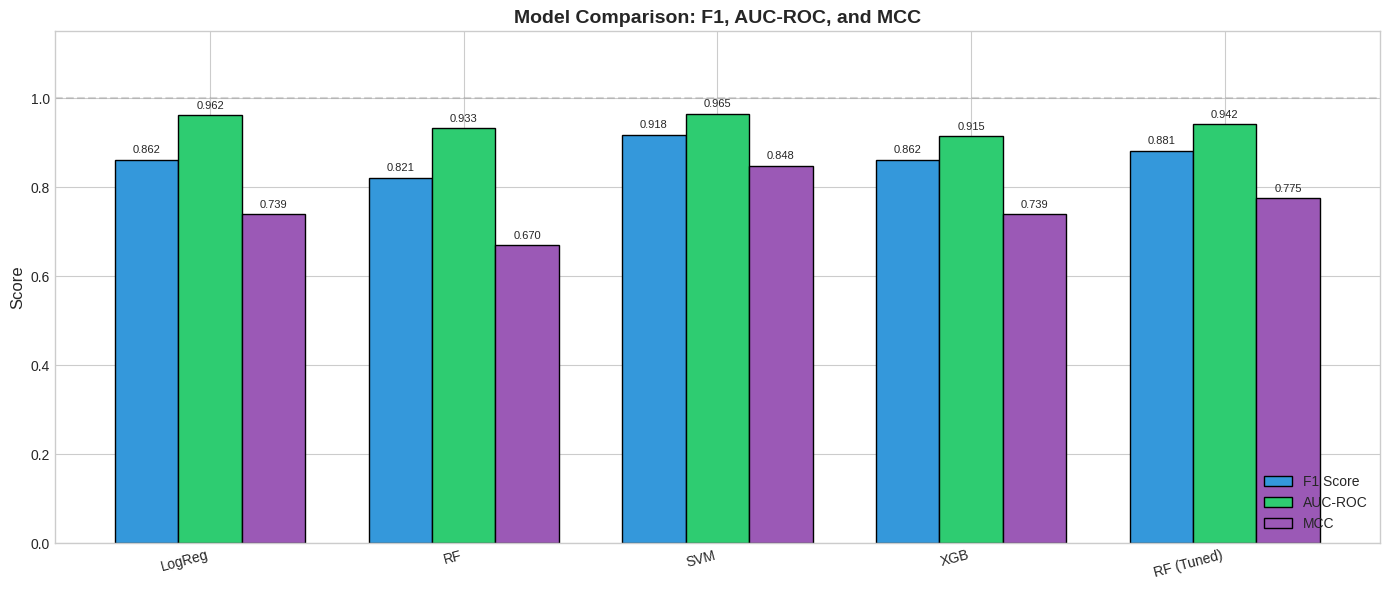

In [19]:
# ============================================================
# Section 6a: Side-by-Side Metric Comparison Bar Chart
# ============================================================
model_names = list(results.keys())
f1_scores = [results[m]['f1'] for m in model_names]
auc_scores = [results[m]['auc'] for m in model_names]
mcc_scores = [results[m]['mcc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, f1_scores, width, label='F1 Score',
               color='#3498DB', edgecolor='black')
bars2 = ax.bar(x, auc_scores, width, label='AUC-ROC',
               color='#2ECC71', edgecolor='black')
bars3 = ax.bar(x + width, mcc_scores, width, label='MCC',
               color='#9B59B6', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: F1, AUC-ROC, and MCC',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


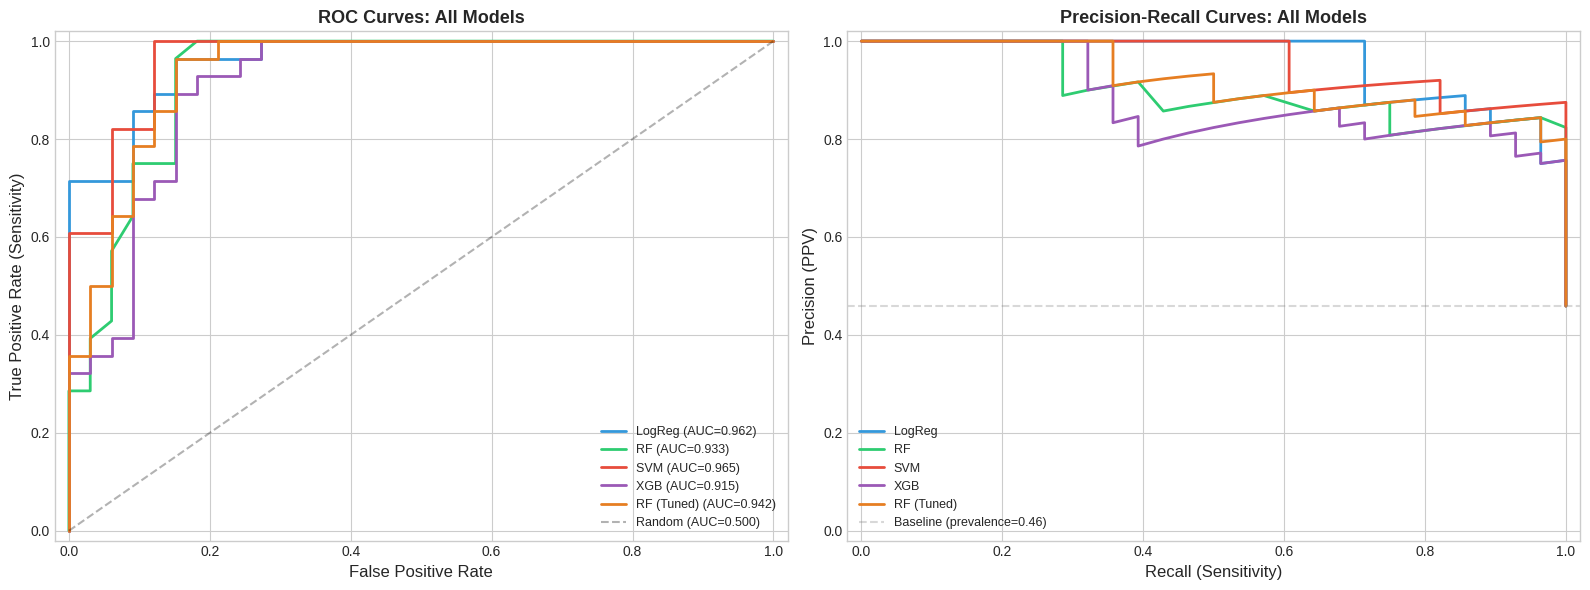

In [20]:
# ============================================================
# Section 6b: ROC Curves + Precision-Recall Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color map for models
colors_map = {'LogReg': '#3498DB', 'RF': '#2ECC71',
              'SVM': '#E74C3C', 'XGB': '#9B59B6', 'RF (Tuned)': '#E67E22'}

# ROC Curves
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    auc = results[name]['auc']
    color = colors_map.get(name, '#333333')
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curves: All Models', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

# Precision-Recall Curves
for name in model_names:
    precision, recall, _ = precision_recall_curve(y_test, results[name]['y_proba'])
    color = colors_map.get(name, '#333333')
    axes[1].plot(recall, precision, color=color, linewidth=2, label=name)

# Baseline = prevalence
prevalence = sum(y_test == 1) / len(y_test)
axes[1].axhline(y=prevalence, color='gray', linestyle='--', alpha=0.3,
                label=f'Baseline (prevalence={prevalence:.2f})')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision (PPV)', fontsize=12)
axes[1].set_title('Precision-Recall Curves: All Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()


### 6c. Confusion Matrix Visualization

The confusion matrix is the foundation of all classification metrics. Let's
visualize it for the best model using sklearn's `ConfusionMatrixDisplay`.

> **Corresponds to Slide ~S19 (Confusion Matrix)**


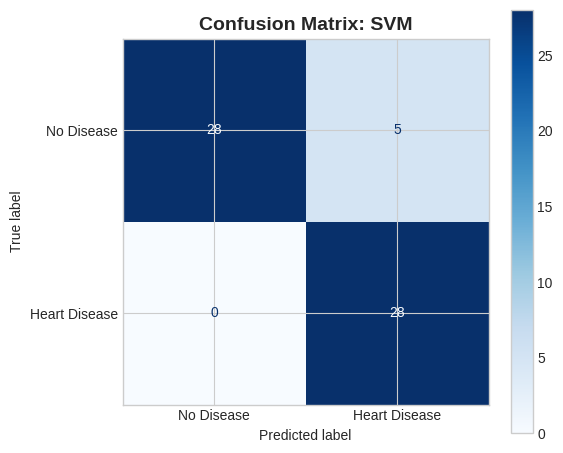


Clinical interpretation for SVM:
  True Negatives (correctly ruled out):  28
  False Positives (unnecessary workups): 5
  False Negatives (MISSED diseases):     0  <- Most dangerous!
  True Positives (correctly detected):   28

  Sensitivity (Recall):  1.000 — catches 100% of heart disease
  Specificity:           0.848 — avoids 85% of false alarms


In [21]:
# ============================================================
# Section 6c: Confusion Matrix for Best Model
# ============================================================
# Find best model by F1
best_model_name = max(results, key=lambda m: results[m]['f1'])
best_y_pred = results[best_model_name]['y_pred']

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_y_pred,
    display_labels=['No Disease', 'Heart Disease'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the clinical interpretation
cm = confusion_matrix(y_test, best_y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nClinical interpretation for {best_model_name}:")
print(f"  True Negatives (correctly ruled out):  {tn}")
print(f"  False Positives (unnecessary workups): {fp}")
print(f"  False Negatives (MISSED diseases):     {fn}  <- Most dangerous!")
print(f"  True Positives (correctly detected):   {tp}")
print(f"\n  Sensitivity (Recall):  {tp/(tp+fn):.3f} — catches {tp/(tp+fn)*100:.0f}% of heart disease")
print(f"  Specificity:           {tn/(tn+fp):.3f} — avoids {tn/(tn+fp)*100:.0f}% of false alarms")


### 6d. Threshold Tuning

By default, we classify as positive when predicted probability > 0.5. But in
clinical settings, **missing a heart attack (False Negative) is far worse than
ordering an extra test (False Positive)**. By lowering the threshold from 0.5
to, say, 0.3, we catch more true positives at the cost of more false positives.

This is exactly the **sensitivity-specificity tradeoff** that clinicians navigate daily.

> **Corresponds to Slide ~S18 (Threshold Tuning)**


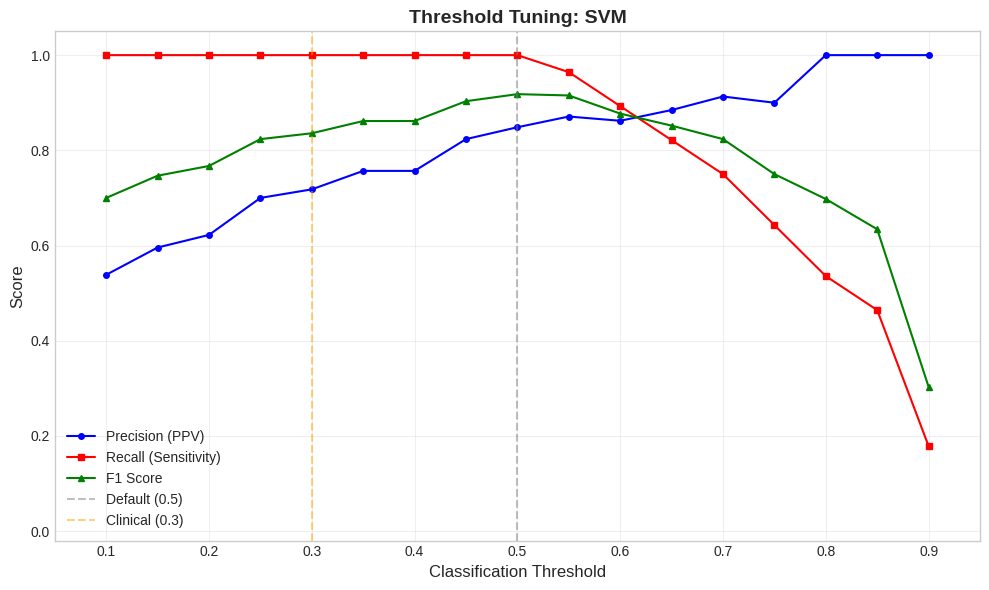


Threshold=0.5: Precision=0.848, Recall=1.000, F1=0.918

Threshold=0.3: Precision=0.718, Recall=1.000, F1=0.836

Clinical insight: lowering threshold from 0.5 to 0.3 improves recall
(catches more heart disease) at the cost of lower precision (more false alarms).
In cardiac screening, higher recall is often preferred — better safe than sorry.


In [22]:
# ============================================================
# Section 6d: Threshold Tuning — Precision/Recall/F1 vs Threshold
# ============================================================
# Use the best model's probabilities
best_proba = results[best_model_name]['y_proba']

thresholds = np.arange(0.1, 0.91, 0.05)
precisions_t, recalls_t, f1s_t = [], [], []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    precisions_t.append(p)
    recalls_t.append(r)
    f1s_t.append(f)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions_t, 'b-o', label='Precision (PPV)', markersize=4)
ax.plot(thresholds, recalls_t, 'r-s', label='Recall (Sensitivity)', markersize=4)
ax.plot(thresholds, f1s_t, 'g-^', label='F1 Score', markersize=4)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Clinical (0.3)')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Tuning: {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare threshold=0.5 vs threshold=0.3
for t in [0.5, 0.3]:
    y_pt = (best_proba >= t).astype(int)
    p = precision_score(y_test, y_pt, zero_division=0)
    r = recall_score(y_test, y_pt, zero_division=0)
    f = f1_score(y_test, y_pt, zero_division=0)
    print(f"\nThreshold={t:.1f}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

print(f"\nClinical insight: lowering threshold from 0.5 to 0.3 improves recall")
print(f"(catches more heart disease) at the cost of lower precision (more false alarms).")
print(f"In cardiac screening, higher recall is often preferred — better safe than sorry.")


In [23]:
# ============================================================
# Section 6e: Declare the Winner (with Caveats)
# ============================================================
# Find best model by F1
best_model = max(results, key=lambda m: results[m]['f1'])
best_f1 = results[best_model]['f1']

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
print(f"\n{'Model':<20} {'F1':>8} {'AUC':>8} {'MCC':>8} {'Acc':>8}")
print("-" * 55)
for name in model_names:
    r = results[name]
    marker = " <-- BEST" if name == best_model else ""
    print(f"{name:<20} {r['f1']:>8.4f} {r['auc']:>8.4f} "
          f"{r['mcc']:>8.4f} {r['accuracy']:>8.4f}{marker}")

print(f"\nWinner by F1: {best_model} (F1={best_f1:.4f})")
print(f"\nIMPORTANT CAVEAT:")
print(f"  On 303 patients with 13 features, model differences are often")
print(f"  within 2-5%. The real differentiators on small datasets are:")
print(f"  1. Interpretability (can you explain the prediction?)")
print(f"  2. Robustness (does it work on new hospital data?)")
print(f"  3. Clinical integration (can the doctor use it in workflow?)")


MODEL COMPARISON RESULTS

Model                      F1      AUC      MCC      Acc
-------------------------------------------------------
LogReg                 0.8621   0.9621   0.7389   0.8689
RF                     0.8214   0.9329   0.6699   0.8361
SVM                    0.9180   0.9654   0.8485   0.9180 <-- BEST
XGB                    0.8621   0.9145   0.7389   0.8689
RF (Tuned)             0.8814   0.9416   0.7745   0.8852

Winner by F1: SVM (F1=0.9180)

IMPORTANT CAVEAT:
  On 303 patients with 13 features, model differences are often
  within 2-5%. The real differentiators on small datasets are:
  1. Interpretability (can you explain the prediction?)
  2. Robustness (does it work on new hospital data?)
  3. Clinical integration (can the doctor use it in workflow?)


## 7. Feature Importance, LIME & SHAP

A cardiologist won't trust a black-box model. They need to know **WHY** the AI
predicts high cardiac risk. Three tools help us explain:

1. **Feature Importance** (built-in to Random Forest) — global: which features
   matter most across ALL patients?
2. **LIME** — local: explain ONE patient's prediction by fitting a simple model nearby
3. **SHAP** (SHapley Additive exPlanations) — both global AND local: game-theory
   based feature attribution

**Clinical scenario:** Your model predicts 87% cardiac risk for a 62-year-old patient.
The cardiologist asks: "Why? Which features? Should I trust this?" If you can't
answer, no doctor will use your AI.

> **Corresponds to Slides ~S43-S47 (Interpretability)**


LIME Explanation for Test Patient #1
  Actual label: No Disease
  P(Heart Disease): 0.420
  Prediction: No Disease

Top feature contributions:
  thal_7.0 <= 0.00: -0.2096 (decreases risk)
  0.00 < cp_4.0 <= 1.00: +0.1624 (increases risk)
  0.00 < sex_1.0 <= 1.00: +0.1012 (increases risk)
  ca_1.0 <= 0.00: -0.0890 (decreases risk)
  thalach > 0.71: -0.0792 (decreases risk)
  slope_2.0 <= 0.00: -0.0749 (decreases risk)
  exang_1.0 <= 0.00: -0.0735 (decreases risk)
  ca_3.0 <= 0.00: -0.0661 (decreases risk)
  ca_2.0 <= 0.00: -0.0575 (decreases risk)
  0.16 < age <= 0.72: +0.0472 (increases risk)


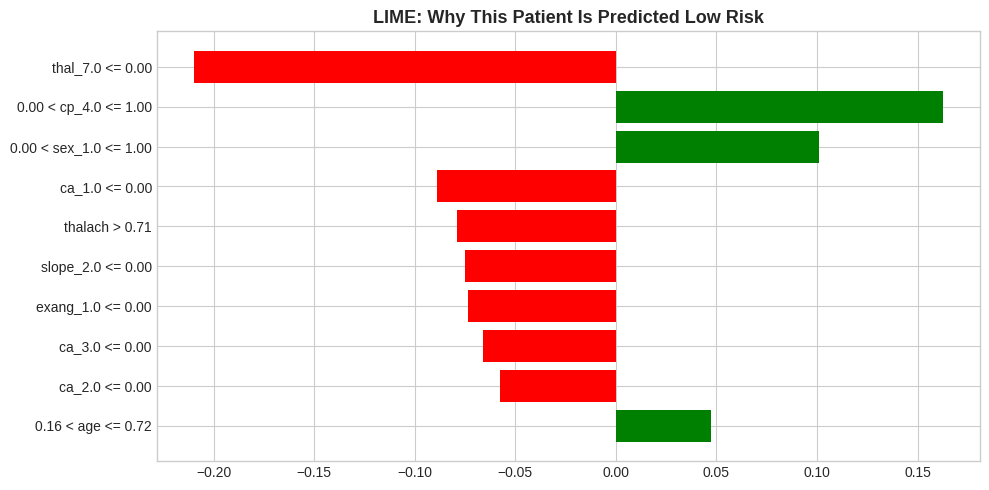


LIME explains ONE patient at a time — good for bedside clinical discussions.


In [24]:
# ============================================================
# Section 7a: LIME — Local Explanations for One Patient
# ============================================================
# Extract the fitted preprocessor from the RF pipeline
# (matching V6 slide S47: models['RF'].named_steps['pre'])
pre = models['RF'].named_steps['pre']
X_train_proc = pre.transform(X_train)
X_test_proc = pre.transform(X_test)

# Get feature names after preprocessing
try:
    feat_names = list(pre.get_feature_names_out())
except AttributeError:
    feat_names = [f'feature_{i}' for i in range(X_train_proc.shape[1])]

# Clean up feature names for readability
feat_names_clean = [n.replace('num__', '').replace('cat__', '') for n in feat_names]

# Create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_proc,
    feature_names=feat_names_clean,
    class_names=['No Disease', 'Heart Disease'],
    mode='classification'
)

# Explain the first test patient
patient_idx = 0
rf_clf = models['RF'].named_steps['clf']
exp = explainer_lime.explain_instance(
    X_test_proc[patient_idx],
    rf_clf.predict_proba,
    num_features=10
)

# Show LIME explanation
print(f"LIME Explanation for Test Patient #{patient_idx + 1}")
print(f"  Actual label: {'Heart Disease' if y_test.iloc[patient_idx] == 1 else 'No Disease'}")
pred_proba_lime = rf_clf.predict_proba(X_test_proc[patient_idx].reshape(1, -1))[0]
print(f"  P(Heart Disease): {pred_proba_lime[1]:.3f}")
print(f"  Prediction: {'Heart Disease' if pred_proba_lime[1] > 0.5 else 'No Disease'}")
print("\nTop feature contributions:")
for feat, weight in exp.as_list():
    direction = "increases" if weight > 0 else "decreases"
    print(f"  {feat}: {weight:+.4f} ({direction} risk)")

# Plot LIME explanation
fig = exp.as_pyplot_figure()
fig.set_size_inches(10, 5)
plt.title(f'LIME: Why This Patient Is Predicted '
          f'{"High" if pred_proba_lime[1] > 0.5 else "Low"} Risk',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLIME explains ONE patient at a time — good for bedside clinical discussions.")


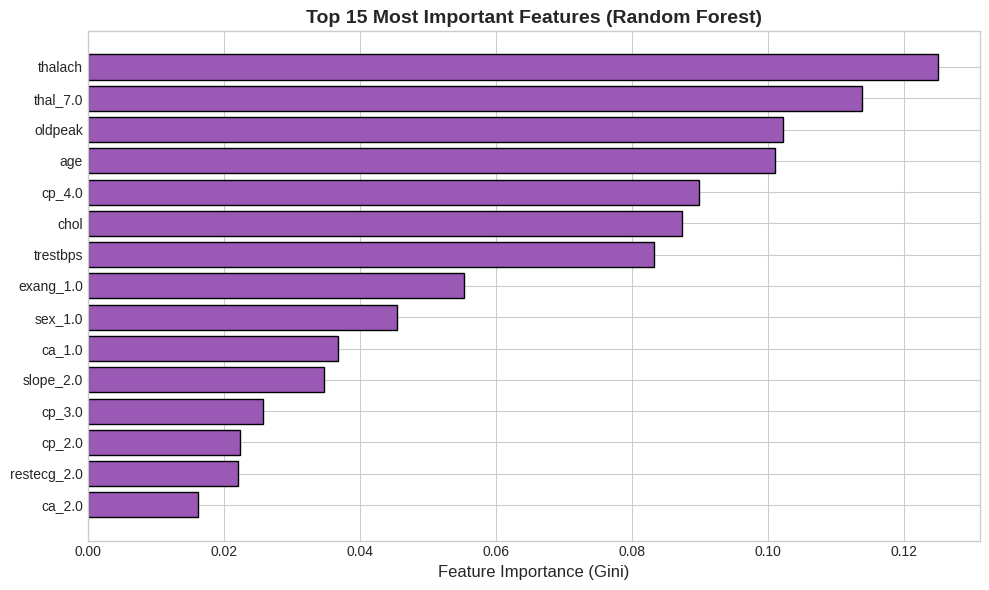

Clinical interpretation:
  -> 'thalach' (max heart rate) is often the top feature — low max HR
     during exercise stress test indicates poor cardiac function
  -> 'ca' (number of major vessels by fluoroscopy) directly shows
     coronary artery disease severity
  -> 'cp' (chest pain type) is a classic clinical indicator


In [25]:
# ============================================================
# Section 7b: Random Forest Feature Importance (Built-in)
# ============================================================
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color='#9B59B6', edgecolor='black')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feat_names_clean[i] for i in indices])
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 15 Most Important Features (Random Forest)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Clinical interpretation:")
print("  -> 'thalach' (max heart rate) is often the top feature — low max HR")
print("     during exercise stress test indicates poor cardiac function")
print("  -> 'ca' (number of major vessels by fluoroscopy) directly shows")
print("     coronary artery disease severity")
print("  -> 'cp' (chest pain type) is a classic clinical indicator")


SHAP values computed for 61 test patients
Shape: (61, 20) (patients x features)
Type: <class 'shap._explanation.Explanation'>

SHAP Summary Plot (Beeswarm)
Each dot is one patient. Red = high feature value, Blue = low.
------------------------------------------------------------


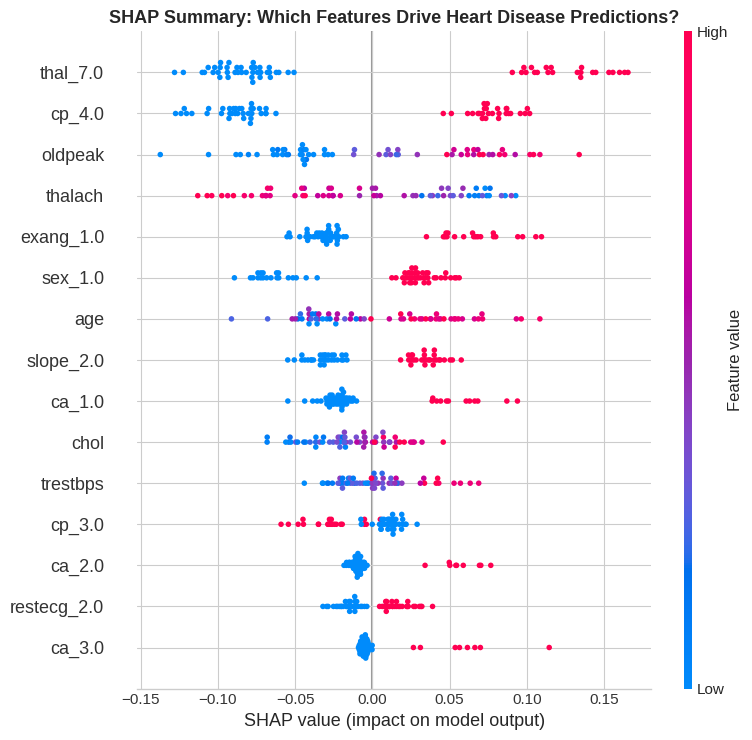


How to read this plot:
  -> Features are ranked by overall importance (top = most important)
  -> Each dot is one patient's SHAP value for that feature
  -> Red dot on the RIGHT = high feature value INCREASES risk
  -> Blue dot on the LEFT = low feature value DECREASES risk
  -> Note: colors reflect standardized values (z-scores), not raw clinical units


In [26]:
# ============================================================
# Section 7c: SHAP TreeExplainer — New API (returns Explanation object)
# ============================================================
# Create SHAP explainer for the RF model
explainer_shap = shap.TreeExplainer(rf_clf)

# New API: explainer(X) returns an Explanation object directly
# (NOT explainer.shap_values() which returns raw arrays)
shap_values = explainer_shap(X_test_proc)

# For binary classification, select class 1 (heart disease)
if len(shap_values.values.shape) == 3:
    shap_values = shap_values[..., 1]  # shape (n_samples, n_features)

print(f"SHAP values computed for {X_test_proc.shape[0]} test patients")
print(f"Shape: {shap_values.values.shape} (patients x features)")
print(f"Type: {type(shap_values)}")

# SHAP Summary Plot (Beeswarm)
print("\nSHAP Summary Plot (Beeswarm)")
print("Each dot is one patient. Red = high feature value, Blue = low.")
print("-" * 60)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values.values, X_test_proc,
                  feature_names=feat_names_clean,
                  show=False, max_display=15)
plt.title('SHAP Summary: Which Features Drive Heart Disease Predictions?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHow to read this plot:")
print("  -> Features are ranked by overall importance (top = most important)")
print("  -> Each dot is one patient's SHAP value for that feature")
print("  -> Red dot on the RIGHT = high feature value INCREASES risk")
print("  -> Blue dot on the LEFT = low feature value DECREASES risk")
print("  -> Note: colors reflect standardized values (z-scores), not raw clinical units")


Explaining prediction for Test Patient #1
  Actual label:      No Disease
  Predicted P(disease): 0.420
  Prediction:        No Disease
------------------------------------------------------------


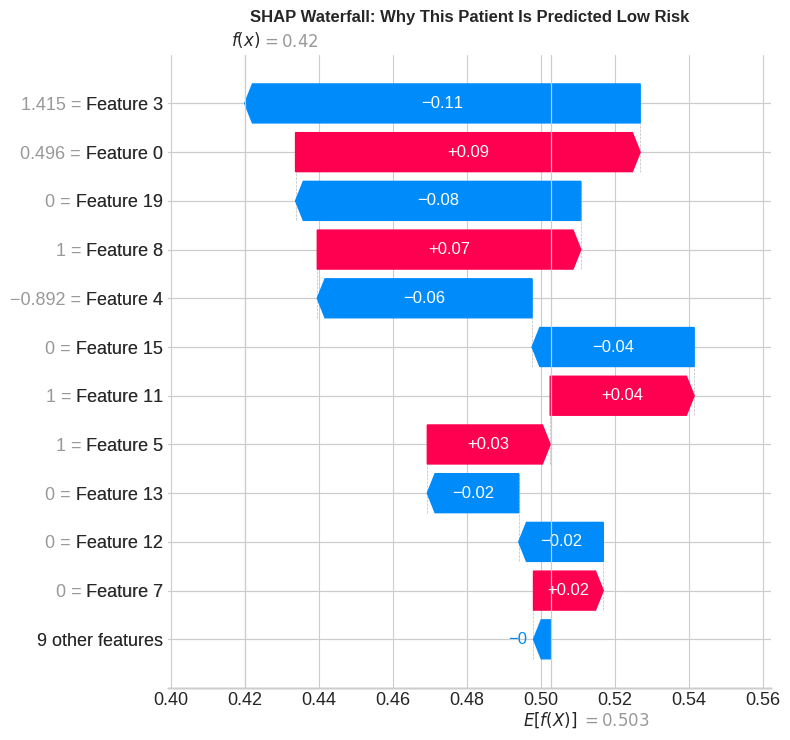


Clinical interpretation for this patient:
  Red bars (positive SHAP) = features that INCREASE predicted risk
  Blue bars (negative SHAP) = features that DECREASE predicted risk
  This is exactly what a cardiologist needs: 'THESE specific features
  drove this specific prediction — and they make clinical sense.'


In [27]:
# ============================================================
# Section 7c (cont): SHAP Waterfall for a Single Patient
# ============================================================
# Use the Explanation object directly — no manual construction needed
patient_idx = 0

print(f"Explaining prediction for Test Patient #{patient_idx + 1}")
print(f"  Actual label:      {'Heart Disease' if y_test.iloc[patient_idx] == 1 else 'No Disease'}")
pred_proba_shap = models['RF'].predict_proba(X_test.iloc[[patient_idx]])[0]
print(f"  Predicted P(disease): {pred_proba_shap[1]:.3f}")
print(f"  Prediction:        {'Heart Disease' if pred_proba_shap[1] > 0.5 else 'No Disease'}")
print("-" * 60)

try:
    # The Explanation object from explainer(X) can be indexed directly
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[patient_idx], show=False, max_display=12)
    plt.title(f'SHAP Waterfall: Why This Patient Is Predicted '
              f'{"High" if pred_proba_shap[1] > 0.5 else "Low"} Risk',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Waterfall plot error: {e}")
    # Fallback: simple bar chart of SHAP values
    top_k = 10
    sv = shap_values.values[patient_idx]
    idx_sorted = np.argsort(np.abs(sv))[-top_k:]
    fig, ax = plt.subplots(figsize=(8, 5))
    colors_shap = ['#E74C3C' if v > 0 else '#3498DB' for v in sv[idx_sorted]]
    ax.barh(range(top_k), sv[idx_sorted], color=colors_shap, edgecolor='black')
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([feat_names_clean[i] for i in idx_sorted])
    ax.set_xlabel('SHAP Value (impact on heart disease prediction)')
    ax.set_title(f'SHAP Values for Patient #{patient_idx + 1}', fontweight='bold')
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nClinical interpretation for this patient:")
print("  Red bars (positive SHAP) = features that INCREASE predicted risk")
print("  Blue bars (negative SHAP) = features that DECREASE predicted risk")
print("  This is exactly what a cardiologist needs: 'THESE specific features")
print("  drove this specific prediction — and they make clinical sense.'")


### 7d. Calibration Curve

A model can have great AUC but misleading probabilities. **Calibration** checks
whether predicted probabilities match actual frequencies — if the model says
"80% risk," do ~80% of similar patients actually have disease?

- **Discrimination** (AUC): can the model rank patients? (higher risk = more likely)
- **Calibration**: are the predicted probabilities accurate?

For clinical decision-making, calibration often matters MORE than AUC.

> **Corresponds to Slide ~S48 (Calibration)**


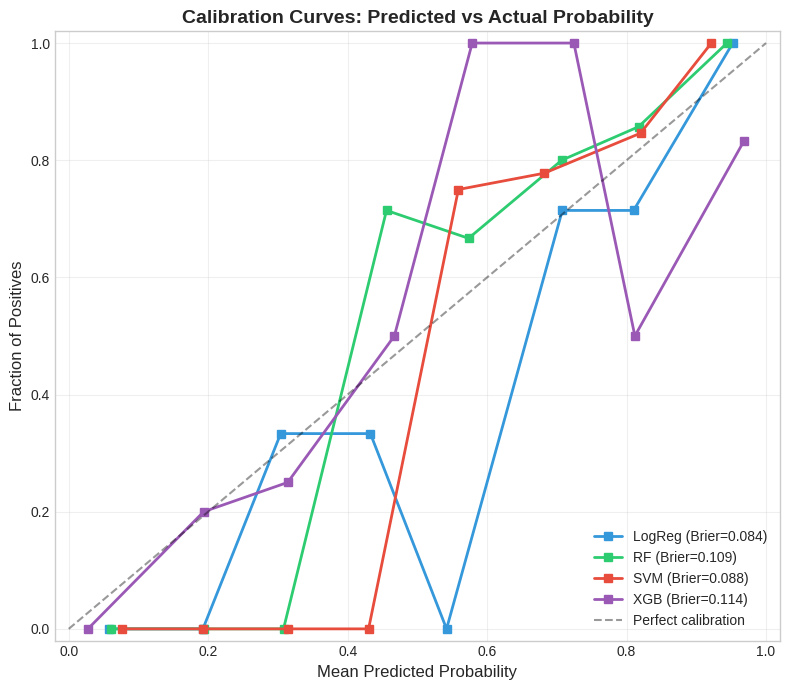


Brier Score (lower = better calibration):
  LogReg    : 0.0843
  RF        : 0.1093
  SVM       : 0.0883
  XGB       : 0.1145

Key insight: Logistic Regression is often well-calibrated out of the box.
Tree ensembles (RF, XGB) may need post-hoc calibration (Platt scaling).
For clinical decision-making, calibrated probabilities are essential —
a doctor needs '80% risk' to truly mean ~80%.


In [28]:
# ============================================================
# Section 7d: Calibration Curves for All Models
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

# Plot calibration curve for each model
for name in ['LogReg', 'RF', 'SVM', 'XGB']:
    if name not in results:
        continue
    prob_true, prob_pred = calibration_curve(
        y_test, results[name]['y_proba'], n_bins=8, strategy='uniform')
    brier = brier_score_loss(y_test, results[name]['y_proba'])
    color = colors_map.get(name, '#333333')
    ax.plot(prob_pred, prob_true, 's-', color=color, linewidth=2,
            label=f'{name} (Brier={brier:.3f})')

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves: Predicted vs Actual Probability',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print Brier scores
print("\nBrier Score (lower = better calibration):")
for name in ['LogReg', 'RF', 'SVM', 'XGB']:
    if name not in results:
        continue
    brier = brier_score_loss(y_test, results[name]['y_proba'])
    print(f"  {name:<10}: {brier:.4f}")

print("\nKey insight: Logistic Regression is often well-calibrated out of the box.")
print("Tree ensembles (RF, XGB) may need post-hoc calibration (Platt scaling).")
print("For clinical decision-making, calibrated probabilities are essential —")
print("a doctor needs '80% risk' to truly mean ~80%.")


## 8. Student Tasks

Complete the following tasks to deepen your understanding. Each task builds on
what you've learned in the notebook. Try them in order.

| Task | Description | Difficulty |
|------|-------------|------------|
| T1 | Change train/test split ratio (0.2 -> 0.3) | ⭐ |
| T2 | Try different imputation strategies | ⭐ |
| T3 | Add GradientBoostingClassifier to the comparison | ⭐⭐ |
| T4 | Try different SMOTE sampling ratios | ⭐⭐ |
| T5 | Build a full ImbPipeline with SMOTE + GridSearchCV | ⭐⭐⭐ |


In [29]:
# ============================================================
# Task 1 (Star): Change train/test split ratio
# ============================================================
# Current: test_size=0.2 (80/20 split)
# TODO: Change to test_size=0.3 (70/30 split) and re-run all 4 models.
#       Does the model ranking change? Are the scores more or less stable?
#
# Hint:
# X_train2, X_test2, y_train2, y_test2 = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y)
#
# Then rebuild ImbPipeline for each classifier:
# for name, clf in classifiers.items():
#     pipe = ImbPipeline([('pre', preprocess), ('clf', clf)])
#     pipe.fit(X_train2, y_train2)
#     ...

# YOUR CODE HERE:



In [30]:
# ============================================================
# Task 2 (Star): Try different imputation strategies
# ============================================================
# Current: SimpleImputer(strategy='median') for numerical columns
# TODO: Try these alternatives and compare:
#   a) strategy='mean'
#   b) KNNImputer(n_neighbors=5) from sklearn.impute
#
# Hint:
# from sklearn.impute import KNNImputer
#
# numerical_transformer_knn = Pipeline(steps=[
#     ('imputer', KNNImputer(n_neighbors=5)),
#     ('scaler', StandardScaler())
# ])
#
# preprocess_knn = ColumnTransformer(transformers=[
#     ('num', numerical_transformer_knn, num_cols),
#     ('cat', categorical_transformer, cat_cols)
# ])

# YOUR CODE HERE:



In [31]:
# ============================================================
# Task 3 (Star-Star): Add GradientBoostingClassifier
# ============================================================
# TODO: Add sklearn's GradientBoostingClassifier as a 5th model.
#
# Hint:
# from sklearn.ensemble import GradientBoostingClassifier
#
# gb_pipe = ImbPipeline([
#     ('pre', preprocess),
#     ('clf', GradientBoostingClassifier(
#         n_estimators=100, learning_rate=0.1,
#         max_depth=3, random_state=42))
# ])
# gb_pipe.fit(X_train, y_train)
# Compare its F1, AUC, MCC with the other 4 models.

# YOUR CODE HERE:



In [32]:
# ============================================================
# Task 4 (Star-Star): Try different SMOTE sampling ratios
# ============================================================
# In Section 3, we used default SMOTE (sampling_strategy='auto' = 1.0).
# TODO: Try sampling_strategy=0.5 and 0.8, and compare F1 scores.
#
# Hint:
# smote_05 = SMOTE(sampling_strategy=0.5, random_state=42)
# X_s05, y_s05 = smote_05.fit_resample(X_imb_train, y_imb_train)
# rf_s05 = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_s05.fit(X_s05, y_s05)
# print(f"F1 (0.5): {f1_score(y_imb_test, rf_s05.predict(X_imb_test)):.4f}")

# YOUR CODE HERE:



In [33]:
# ============================================================
# Task 5 (Star-Star-Star): Full ImbPipeline with SMOTE + GridSearchCV
# ============================================================
# TODO: Build a single ImbPipeline: preprocess -> SMOTE -> RF
#       Then wrap it in GridSearchCV for tuning.
#
# Hint:
# imb_pipeline = ImbPipeline([
#     ('pre', preprocess),
#     ('smote', SMOTE(random_state=42)),
#     ('clf', RandomForestClassifier(random_state=42))
# ])
#
# param_grid = {
#     'smote__sampling_strategy': [0.5, 0.8, 1.0],
#     'clf__n_estimators': [100, 200],
#     'clf__max_depth': [5, 10, None],
# }
#
# grid = GridSearchCV(imb_pipeline, param_grid, cv=5,
#                     scoring='f1', n_jobs=-1)
# grid.fit(X_train, y_train)
# print(f"Best params: {grid.best_params_}")
# print(f"Best F1: {grid.best_score_:.4f}")

# YOUR CODE HERE:



## 9. Gemini AI Exercise

Use Google Colab's built-in **Gemini AI** to explore supervised learning concepts.
These prompts are designed to deepen your understanding of imbalance handling,
pipeline construction, and clinical interpretability.

> **Note:** The `google.colab.ai` module is only available in the Colab environment.
> If running locally, the prompts are printed for you to try in the Colab sidebar.


In [34]:
# ============================================================
# Section 9a: Gemini Prompt 1 — The Accuracy Trap
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 1: Explain the accuracy trap in imbalanced data")
    print("=" * 60)
    response = ai.generate_text(
        "I have a clinical dataset with 99% normal and 1% abnormal cases. "
        "My model achieves 99% accuracy but F1-score is 0.0 for the minority class. "
        "Explain why this happens and suggest 3 approaches to fix it, "
        "including code examples for each approach using scikit-learn."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("This section works only in Google Colab.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print('-' * 60)
    print('"I have a clinical dataset with 99% normal and 1% abnormal cases.')
    print('My model achieves 99% accuracy but F1-score is 0.0 for the minority')
    print('class. Explain why this happens and suggest 3 approaches to fix it,')
    print('including code examples for each approach using scikit-learn."')


Gemini Prompt 1: Explain the accuracy trap in imbalanced data
This is a classic problem with imbalanced datasets, and your observations are spot on. Let's break down why this happens and then explore solutions.

---

### Why does 99% Accuracy result in 0.0 F1-score for the minority class?

1.  **The Accuracy Paradox:** When your dataset is highly imbalanced (like 99% normal, 1% abnormal), a model can achieve very high accuracy by simply predicting the majority class for *every* case.
    *   If your model always predicts "Normal" (the majority class), it will be correct for 99% of the cases. This gives you 99% accuracy.
    *   However, it will misclassify *all* the "Abnormal" cases.

2.  **Understanding F1-score for the Minority Class:**
    The F1-score is the harmonic mean of Precision and Recall.
    *   **Precision (for minority class):** $TP / (TP + FP)$
    *   **Recall (for minority class):** $TP / (TP + FN)$
    *   **F1-score:** $2 \cdot \frac{\text{Precision} \cdot \text{Rec

In [35]:
# ============================================================
# Section 9b: Gemini Prompt 2 — Pipeline with SMOTE + GridSearchCV
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 2: Build a complete ML pipeline")
    print("=" * 60)
    response = ai.generate_text(
        "Write an imblearn Pipeline (ImbPipeline) that combines "
        "ColumnTransformer (StandardScaler for numerical features, "
        "OneHotEncoder for categorical features), SMOTE for oversampling "
        "the minority class, and RandomForestClassifier with "
        "class_weight='balanced'. Include GridSearchCV for hyperparameter "
        "tuning with 5-fold stratified cross-validation. Use F1 as the "
        "scoring metric."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print('-' * 60)
    print('"Write an imblearn Pipeline (ImbPipeline) that combines')
    print('ColumnTransformer, SMOTE, and RandomForestClassifier with')
    print('class_weight=balanced. Include GridSearchCV for tuning')
    print('with 5-fold stratified CV and F1 scoring."')



Gemini Prompt 2: Build a complete ML pipeline
This example demonstrates how to construct an `ImbPipeline` with `ColumnTransformer`, `SMOTE`, `RandomForestClassifier`, and `GridSearchCV` for hyperparameter tuning on an imbalanced dataset.

**Key Components:**

1.  **`ColumnTransformer`**: Handles different preprocessing steps for different types of features.
    *   `StandardScaler` for numerical features.
    *   `OneHotEncoder` for categorical features.
2.  **`SMOTE`**: Synthetic Minority Over-sampling Technique to address class imbalance. It generates synthetic samples for the minority class.
3.  **`RandomForestClassifier`**: A robust ensemble classifier. We use `class_weight='balanced'` to give more importance to the minority class during training.
4.  **`ImbPipeline`**: `imblearn`'s version of `Pipeline`. It's crucial because `SMOTE` (an oversampler) modifies the dataset's size, which standard `sklearn` pipelines don't handle correctly within cross-validation. `ImbPipeline` ensure

In [36]:
# ============================================================
# Section 9c: Gemini Prompt 3 — Explain SHAP to a Cardiologist
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 3: Translate SHAP for a clinician")
    print("=" * 60)
    response = ai.generate_text(
        "Explain this SHAP summary plot for a heart disease prediction model "
        "to a cardiologist who has never seen one. The top features are: "
        "ca (number of major vessels colored by fluoroscopy), "
        "thalach (maximum heart rate achieved during exercise), and "
        "cp (chest pain type). What does each dot represent? How do the "
        "colors work? What does it mean when a feature has high SHAP value? "
        "Use clinical language the cardiologist would understand, not ML jargon."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print('-' * 60)
    print('"Explain a SHAP summary plot for heart disease prediction to a')
    print('cardiologist. Top features: ca (major vessels by fluoroscopy),')
    print('thalach (max heart rate during exercise), cp (chest pain type).')
    print('What does each dot represent? How do colors work? Use clinical')
    print('language, not ML jargon."')



Gemini Prompt 3: Translate SHAP for a clinician
Okay, imagine this plot as a way for our computer-based predictive tool to explain *its reasoning* behind estimating a patient's risk of heart disease. It’s like getting a detailed second opinion from the computer, not just a 'yes' or 'no' answer.

Let's break it down:

**Overall Purpose:**
This is a summary plot showing the most important clinical factors the predictive tool used to assess heart disease risk, and how each factor influenced that risk for *individual patients*. The factors are listed on the left, ordered by how much they generally influence the predictions, with the most influential at the top.

---

**What Does Each Dot Represent?**

*   **Each individual dot on this plot represents one of your patients.**
*   For each patient, the dot shows how much a particular clinical factor (like `ca` or `thalach`) *pushed their estimated risk of heart disease up or down*.

---

**How Do the Colors Work?**

*   The color of each dot

## 10. Summary & Self-Check

### Key Takeaways

1. **Data preprocessing is 80% of the work** — imputation, encoding, scaling must be
   done correctly via Pipeline to prevent data leakage
2. **Class imbalance kills naive models** — a model with 99% accuracy can miss every
   cardiac event; use SMOTE, class_weight='balanced', or both
3. **Accuracy is not enough** — use F1, AUC-ROC, MCC, and Precision-Recall curves
   for imbalanced clinical data
4. **Ensemble methods (RF, XGBoost) often win on tabular data** — but on small datasets
   (<500 rows), the gap between algorithms is surprisingly small
5. **Hyperparameter tuning matters** — GridSearchCV systematically finds the best
   combination with cross-validation, replacing manual trial-and-error
6. **Interpretability is non-negotiable in clinical AI** — LIME for quick bedside checks,
   SHAP for global importance and regulatory-grade explanations
7. **Calibration matters as much as discrimination** — AUC tells ranking, calibration
   tells probability accuracy; LogReg is often well-calibrated out of the box
8. **Threshold tuning** adjusts the sensitivity-specificity tradeoff for clinical needs

### Self-Check Checklist

- [ ] I can build a preprocessing Pipeline with ColumnTransformer
- [ ] I understand why 99% accuracy can mean 100% failure on imbalanced data
- [ ] I can apply SMOTE and class_weight='balanced' and explain when to use each
- [ ] I trained and compared 4+ classifiers using ImbPipeline
- [ ] I used GridSearchCV to tune hyperparameters with cross-validation
- [ ] I can generate and interpret LIME explanations for individual patients
- [ ] I can generate and interpret SHAP plots for clinical stakeholders
- [ ] I know how to read a calibration curve and Brier score
- [ ] I can adjust the classification threshold for clinical priorities

### Next Week Preview

**Week 5: Biomedical Signals — ECG Processing and Wearable AI**
- Today: tabular data pipeline (structured features in columns)
- Next week: raw signals (time-series waveforms from sensors)
- Clinical scenario: an EMT's portable ECG + AI detects STEMI in 12 seconds,
  auto-alerts the nearest cath lab — 30 minutes faster than traditional workflow.
  Those 30 minutes = surviving heart muscle.
- Prepare: review feature engineering (Week 4 concepts) and evaluation metrics


In [37]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 60)
print("Congratulations! You've completed Week 4 Notebook!")
print("Supervised Learning Practical: From Messy Data to Trusted Models")
print("=" * 60)

print(f"\nDataset: UCI Heart Disease (Cleveland)")
print(f"  Patients: {df.shape[0]}, Features: {df.shape[1] - 1}")

print(f"\nModel Results (Test Set):")
print(f"  {'Model':<20} {'F1':>8} {'AUC':>8} {'MCC':>8}")
print(f"  {'-'*50}")
for name in results:
    r = results[name]
    print(f"  {name:<20} {r['f1']:>8.4f} {r['auc']:>8.4f} {r['mcc']:>8.4f}")

best = max(results, key=lambda m: results[m]['f1'])
print(f"\nBest model by F1: {best} (F1={results[best]['f1']:.4f})")

print(f"\nKey lessons:")
print(f"  1. Pipeline prevents data leakage (fit on train, transform both)")
print(f"  2. SMOTE on training data only (never on test set)")
print(f"  3. class_weight='balanced' is a simpler alternative to SMOTE")
print(f"  4. F1 and MCC > accuracy for imbalanced clinical data")
print(f"  5. LIME for local, SHAP for global+local explanations")
print(f"  6. Calibration: does P=0.8 truly mean 80% disease rate?")
print(f"  7. Threshold tuning trades precision for recall (clinical needs)")
print(f"  8. On small datasets, model choice matters less than data quality")

print(f"\nNext week: Biomedical Signals (ECG, wearable AI)")
print(f"  Raw time-series signals -> feature engineering -> classification")


Congratulations! You've completed Week 4 Notebook!
Supervised Learning Practical: From Messy Data to Trusted Models

Dataset: UCI Heart Disease (Cleveland)
  Patients: 303, Features: 13

Model Results (Test Set):
  Model                      F1      AUC      MCC
  --------------------------------------------------
  LogReg                 0.8621   0.9621   0.7389
  RF                     0.8214   0.9329   0.6699
  SVM                    0.9180   0.9654   0.8485
  XGB                    0.8621   0.9145   0.7389
  RF (Tuned)             0.8814   0.9416   0.7745

Best model by F1: SVM (F1=0.9180)

Key lessons:
  1. Pipeline prevents data leakage (fit on train, transform both)
  2. SMOTE on training data only (never on test set)
  3. class_weight='balanced' is a simpler alternative to SMOTE
  4. F1 and MCC > accuracy for imbalanced clinical data
  5. LIME for local, SHAP for global+local explanations
  6. Calibration: does P=0.8 truly mean 80% disease rate?
  7. Threshold tuning trades pre